In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns',None)

In [2]:
df=pd.read_excel(r"C:\Users\aisha\OneDrive\Desktop\sale_data.csv.xlsx")
df

,Order Date,Product,Quantity Ordered,Price Each
0,2024-01-01,Laptop,2,50000
1,2024-01-02,Mouse,3,3000
2,2024-01-03,Keyboard,2,400
3,2024-01-04,Monitor,1,6000
4,2024-01-05,Laptop,3,2000
5,2024-01-06,Joystick,2,6000
6,2024-01-07,CD,3,20000
7,2024-01-08,DVD,1,900
8,2024-01-09,USB,2,700
9,2024-01-10,CPU,4,800


In [3]:
print(df.shape)

(10, 4)


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0     Order Date        10 non-null     datetime64[ns]
 1     Product           10 non-null     object        
 2     Quantity Ordered  10 non-null     int64         
 3     Price Each        10 non-null     int64         
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 452.0+ bytes
None


In [5]:
print(df.describe())

                Order Date  Quantity Ordered    Price Each
count                   10         10.000000     10.000000
mean   2024-01-05 12:00:00          2.300000   8980.000000
min    2024-01-01 00:00:00          1.000000    400.000000
25%    2024-01-03 06:00:00          2.000000    825.000000
50%    2024-01-05 12:00:00          2.000000   2500.000000
75%    2024-01-07 18:00:00          3.000000   6000.000000
max    2024-01-10 00:00:00          4.000000  50000.000000
std                    NaN          0.948683  15565.974289


In [6]:
df.isnull().sum()

Order Date          0
Product             0
Quantity Ordered    0
Price Each          0
dtype: int64

In [7]:
df.dropna(inplace=True)
df

,Order Date,Product,Quantity Ordered,Price Each
0,2024-01-01,Laptop,2,50000
1,2024-01-02,Mouse,3,3000
2,2024-01-03,Keyboard,2,400
3,2024-01-04,Monitor,1,6000
4,2024-01-05,Laptop,3,2000
5,2024-01-06,Joystick,2,6000
6,2024-01-07,CD,3,20000
7,2024-01-08,DVD,1,900
8,2024-01-09,USB,2,700
9,2024-01-10,CPU,4,800


In [8]:
print(df.columns)

Index(['  Order Date', '  Product', '  Quantity Ordered', '  Price Each'], dtype='object')


In [13]:
df['Order Date']=pd.to_datetime(df['Order Date'])
df['Order Date']

0   2024-01-01
1   2024-01-02
2   2024-01-03
3   2024-01-04
4   2024-01-05
5   2024-01-06
6   2024-01-07
7   2024-01-08
8   2024-01-09
9   2024-01-10
Name: Order Date, dtype: datetime64[ns]

In [14]:
df['sale']=df['Quantity Ordered']*df['Price Each']
df['sale']

0    100000
1      9000
2       800
3      6000
4      6000
5     12000
6     60000
7       900
8      1400
9      3200
Name: sale, dtype: int64

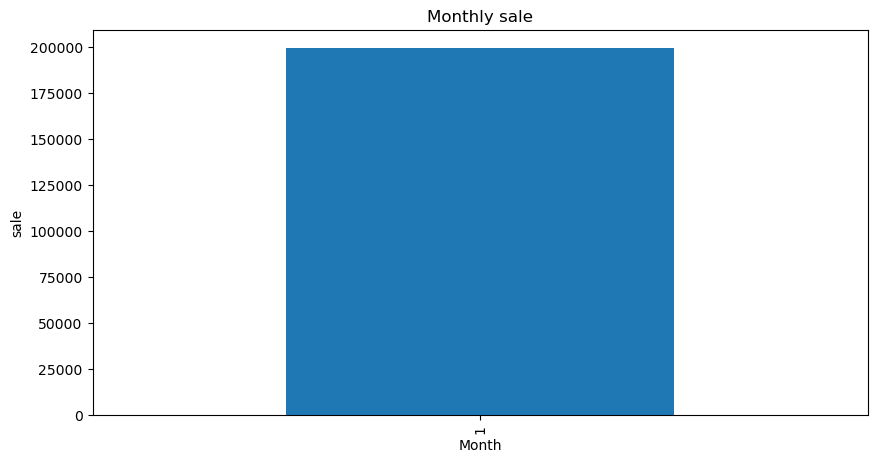

In [16]:
df['Month']=df['Order Date'].dt.month
monthly_sale=df.groupby('Month')['sale'].sum()

monthly_sale.plot(kind='bar',figsize=(10,5))
plt.title('Monthly sale')
plt.xlabel('Month')
plt.ylabel('sale')
plt.show()

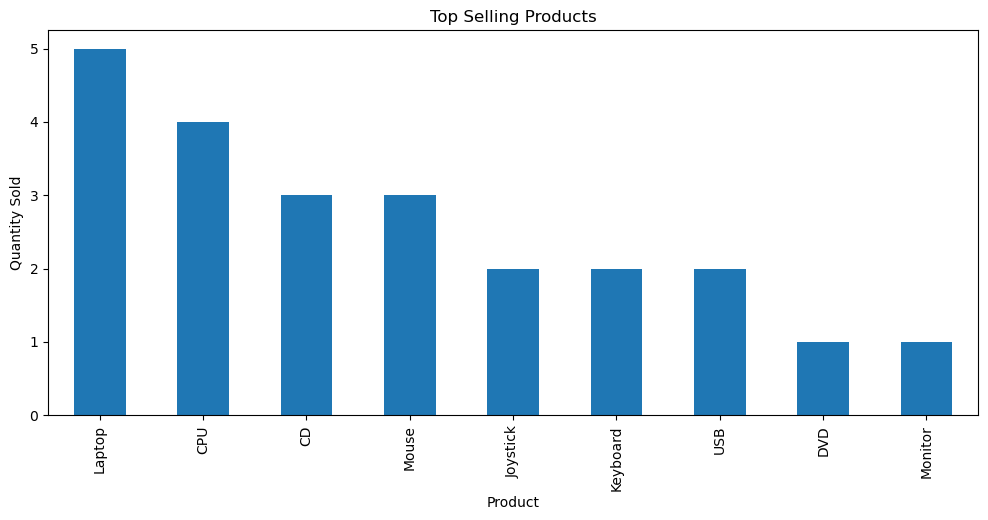

In [17]:
top_products = df.groupby('Product')['Quantity Ordered'].sum().sort_values(ascending=False)

top_products.head(10).plot(kind='bar', figsize=(12,5))
plt.title('Top Selling Products')
plt.xlabel('Product')
plt.ylabel('Quantity Sold')
plt.show()

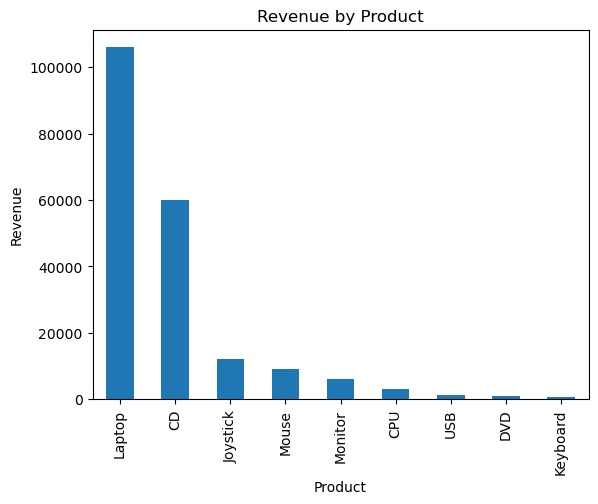

In [19]:
revenue = df.groupby('Product')['sale'].sum().sort_values(ascending=False)

revenue.head(10).plot(kind='bar')
plt.title('Revenue by Product')
plt.xlabel('Product')
plt.ylabel('Revenue')
plt.show()

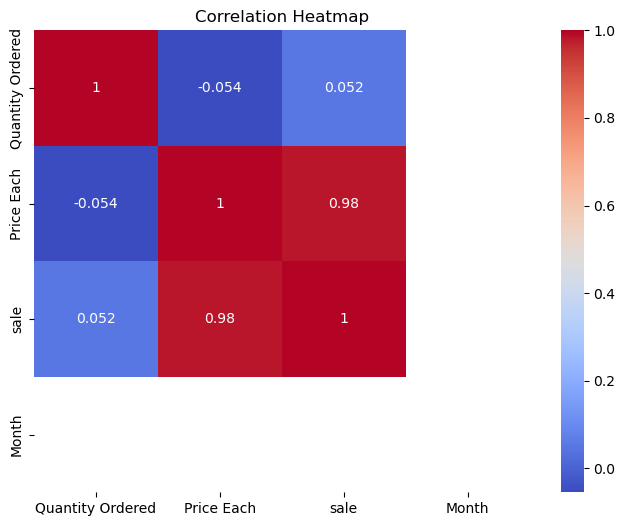

In [20]:
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [26]:
df.to_excel("cleaned_sale_data.xlsx", index=False)
df

,Order Date,Product,Quantity Ordered,Price Each,sale,Month
0,2024-01-01,Laptop,2,50000,100000,1
1,2024-01-02,Mouse,3,3000,9000,1
2,2024-01-03,Keyboard,2,400,800,1
3,2024-01-04,Monitor,1,6000,6000,1
4,2024-01-05,Laptop,3,2000,6000,1
5,2024-01-06,Joystick,2,6000,12000,1
6,2024-01-07,CD,3,20000,60000,1
7,2024-01-08,DVD,1,900,900,1
8,2024-01-09,USB,2,700,1400,1
9,2024-01-10,CPU,4,800,3200,1


In [27]:
df.describe()

,Order Date,Quantity Ordered,Price Each,sale,Month
count,10,10.000000,10.000000,10.000000,10.0
mean,2024-01-05 12:00:00,2.300000,8980.000000,19930.000000,1.0
min,2024-01-01 00:00:00,1.000000,400.000000,800.000000,1.0
25%,2024-01-03 06:00:00,2.000000,825.000000,1850.000000,1.0
50%,2024-01-05 12:00:00,2.000000,2500.000000,6000.000000,1.0
75%,2024-01-07 18:00:00,3.000000,6000.000000,11250.000000,1.0
max,2024-01-10 00:00:00,4.000000,50000.000000,100000.000000,1.0
std,NaN,0.948683,15565.974289,33230.844106,0.0


In [33]:
product_sale=df.groupby('Product')['sale'].sum()
product_sale

Product
CD           60000
CPU           3200
DVD            900
Joystick     12000
Keyboard       800
Laptop      106000
Monitor       6000
Mouse         9000
USB           1400
Name: sale, dtype: int64

In [34]:
highest_product = product_sale.idxmax()
highest_sale = product_sale.max()

print("Highest Selling Product:", highest_product)
print("Sale Amount:", highest_sale)

Highest Selling Product: Laptop
Sale Amount: 106000


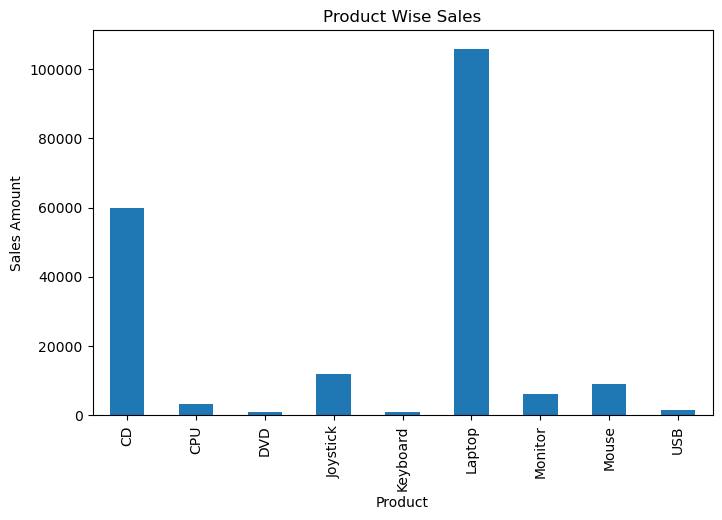

In [36]:
import matplotlib.pyplot as plt

product_sales = df.groupby('Product')['sale'].sum()

product_sales.plot(kind='bar', figsize=(8,5))
plt.title('Product Wise Sales')
plt.xlabel('Product')
plt.ylabel('Sales Amount')
plt.show()

In [37]:
top_products = df.groupby('Product')['Quantity Ordered'].sum()
print(top_products)

Product
CD          3
CPU         4
DVD         1
Joystick    2
Keyboard    2
Laptop      5
Monitor     1
Mouse       3
USB         2
Name: Quantity Ordered, dtype: int64


In [ ]:
print("Total sale =", df['sales'].sum())